In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Начнем с EDA

In [3]:
train = pd.read_csv("data/train.csv")
test =  pd.read_csv("data/test.csv")
test_ids = test["ID"].copy()

print(train.info())
print(test.info())
print(train.head())
print(train["RiskScore"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

## Основная информация по каждому признаку

In [4]:
print(test.isna().sum())
print(train.describe())


ID                            0
ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
EmploymentStatus              0
EducationLevel                0
Experience                    0
NetWorth                      0
BaseInte

## Проверим наличие "пустых" none значений

In [5]:
none_values = train.isna().sum()
none_percent = (none_values / len(train)) * 100

print(none_percent)

train_without_none = train.dropna()
train_filled = train.copy()

# Заполняем пропуски
num_features = train_filled.select_dtypes(include="number").columns
train_filled[num_features] = train_filled[num_features].fillna(train_filled[num_features].mean())

categorial_features = train_filled.select_dtypes("object").columns
for col in categorial_features:
    train_filled[col] = train_filled[col].fillna(train_filled[col].mode()[0])

pre_df = train_without_none.copy()
pre_test = test.copy()


ApplicationDate               4.810747
Age                           4.810747
AnnualIncome                  4.810747
CreditScore                   9.358265
LoanAmount                    9.358265
LoanDuration                  4.810747
MaritalStatus                 4.810747
NumberOfDependents            4.810747
HomeOwnershipStatus           4.810747
MonthlyDebtPayments           9.358265
CreditCardUtilizationRate     4.810747
NumberOfOpenCreditLines       4.810747
NumberOfCreditInquiries       4.810747
DebtToIncomeRatio             4.810747
BankruptcyHistory             9.358265
LoanPurpose                   9.358265
PreviousLoanDefaults          4.810747
PaymentHistory                4.810747
LengthOfCreditHistory         4.810747
SavingsAccountBalance         4.810747
CheckingAccountBalance        9.358265
TotalAssets                   9.358265
TotalLiabilities              4.810747
MonthlyIncome                 4.810747
UtilityBillsPaymentHistory    4.810747
JobTenure                

# Попробуем изменить некоторые категориальные признаки на числовые

In [6]:
# Начнем с логичного HomeOwnershipStatus (Если есть свое жилье - риск минимальный):

home_status_map = {"Own" : 0, "Mortgage" : 1, "Rent" : 2, "Other" : 3}
pre_df["HomeOwnershipStatus_num"] = pre_df["HomeOwnershipStatus"].map(home_status_map)
pre_test["HomeOwnershipStatus_num"] = pre_test["HomeOwnershipStatus"].map(home_status_map)

# Также хороший вариант это EmploymentStatus (Работаешь - риск минимальный):
employment_status_map = {"Employed" : 0, "Self-Employed" : 1, "Unemployed" : 2}
pre_df["EmploymentStatus_num"] = pre_df["EmploymentStatus"].map(employment_status_map)
pre_test["EmploymentStatus_num"] = pre_test["EmploymentStatus"].map(employment_status_map)

# Заметим упорядоченный признак EducationLevel (минимальный риск - умные люди)
education_map = { 'Doctorate': 0, 'Master': 1, 'Bachelor': 2, 'Associate': 3, 'High School': 4}
pre_df["EducationLevel_num"] = pre_df["EducationLevel"].map(education_map)
pre_test["EducationLevel_num"] = pre_test["EducationLevel"].map(education_map)

# Можно еще что-нибудь придумать с MaritalStatus и LoanPurpose
marital_map = { 'Married': 0, 'Single': 1, 'Divorced': 2, 'Widowed': 3 }
pre_df["MaritalStatus_num"] = pre_df["MaritalStatus"].map(marital_map)
pre_test["MaritalStatus_num"] = pre_test["MaritalStatus"].map(marital_map)

loan_purpose_map = { 'Home': 0, 'Auto': 1, 'Education': 2, 'Debt Consolidation': 3, 'Other': 4 }
pre_df['LoanPurpose_num'] = pre_df['LoanPurpose'].map(loan_purpose_map)
pre_test['LoanPurpose_num'] = pre_test['LoanPurpose'].map(loan_purpose_map)

## Проверим на аномалии в столбцах

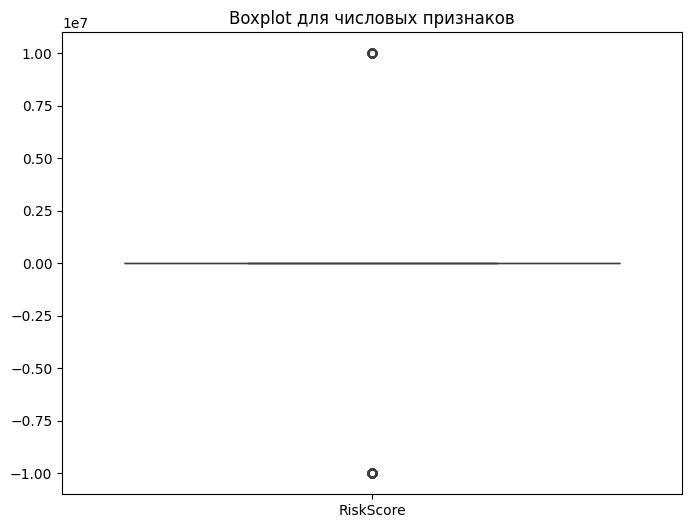

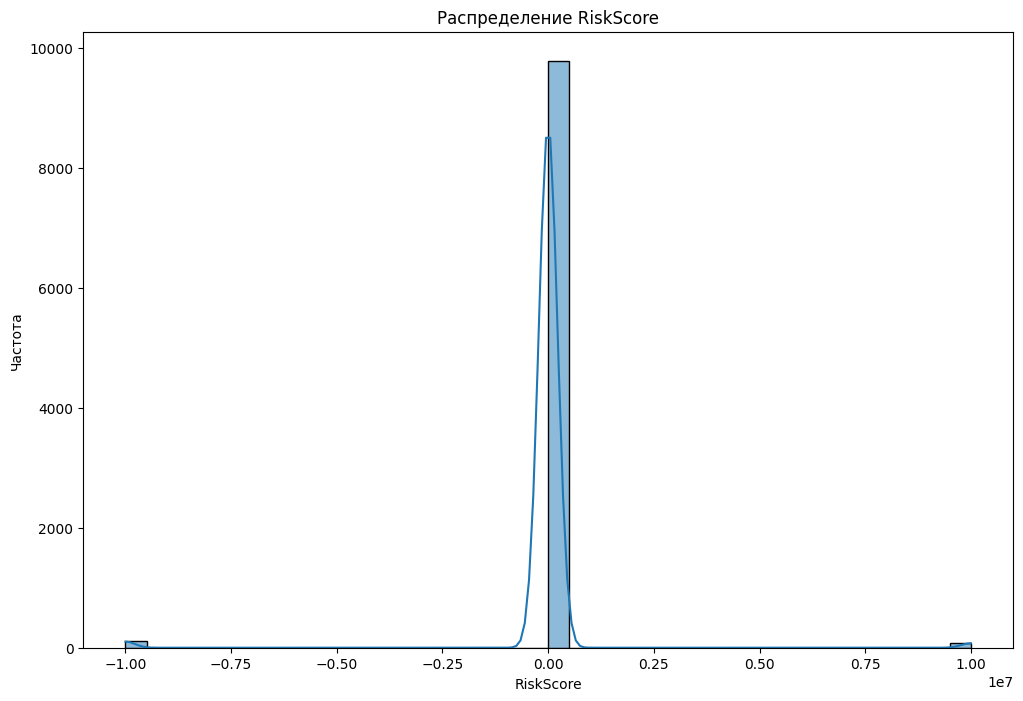

count    9.986000e+03
mean    -3.099606e+04
std      1.411392e+06
min     -9.999999e+06
25%      3.251016e+01
50%      4.406128e+01
75%      6.532677e+01
max      1.000000e+07
Name: RiskScore, dtype: float64
92.79116783385172


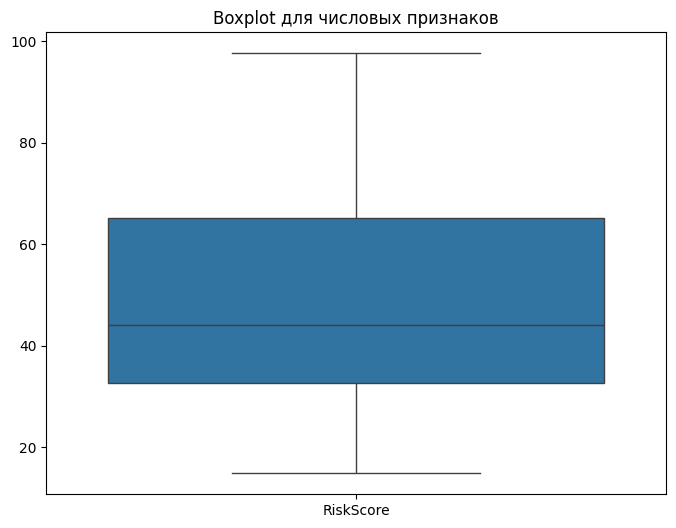

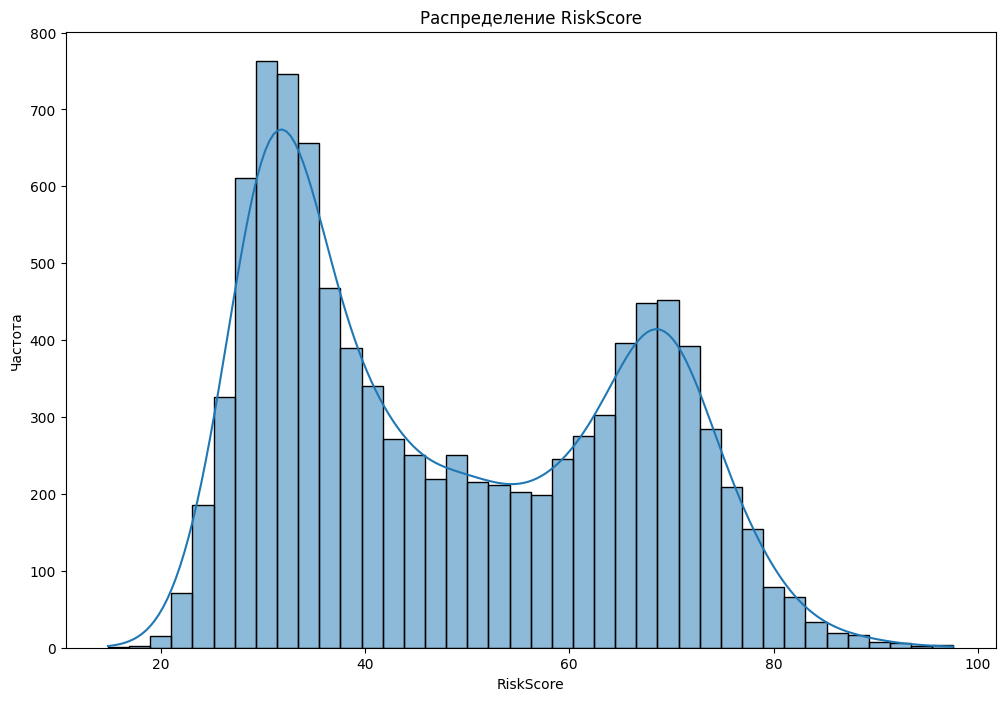

In [7]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=pre_df[['RiskScore']])
plt.title("Boxplot для числовых признаков")
plt.show()

plt.figure(figsize=(12, 8))
sns.histplot(pre_df['RiskScore'], bins=40, kde=True)
plt.title("Распределение RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Частота")
plt.show()

# Есть аномалии, RiskScore не может быть отрицательным и очень большим

print(pre_df["RiskScore"].describe())
print(pre_df["RiskScore"].quantile(0.991)) # примерно можно взять 100, что больше 100 мы удаляем
df = pre_df.copy()
df_test = pre_test.copy()
df = df[(df["RiskScore"] >= 0) & (df["RiskScore"] < 100)]

# Построим новый график
plt.figure(figsize=(8, 6))

sns.boxplot(data=df[['RiskScore']])
plt.title("Boxplot для числовых признаков")
plt.show()

plt.figure(figsize=(12, 8))
sns.histplot(df['RiskScore'], bins=40, kde=True)
plt.title("Распределение RiskScore")
plt.xlabel("RiskScore")
plt.ylabel("Частота")
plt.show()






## Построим матрицу корреляций для числовых признаков 

                                 Age  AnnualIncome  CreditScore  LoanAmount  \
Age                         1.000000      0.039471     0.056968    0.006178   
AnnualIncome                0.039471      1.000000     0.617930    0.002974   
CreditScore                 0.056968      0.617930     1.000000   -0.003894   
LoanAmount                  0.006178      0.002974    -0.003894    1.000000   
LoanDuration                0.019498     -0.017199    -0.014434   -0.007074   
NumberOfDependents          0.018494     -0.004079    -0.001750    0.003523   
MonthlyDebtPayments        -0.013430      0.010828     0.006162   -0.001433   
CreditCardUtilizationRate   0.026346     -0.009095    -0.010263   -0.014944   
NumberOfOpenCreditLines    -0.003938      0.003477    -0.000313    0.001009   
NumberOfCreditInquiries    -0.001098      0.014758     0.006429   -0.000054   
DebtToIncomeRatio          -0.005035      0.009278     0.012618   -0.007260   
BankruptcyHistory           0.005132     -0.000043  

<Axes: >

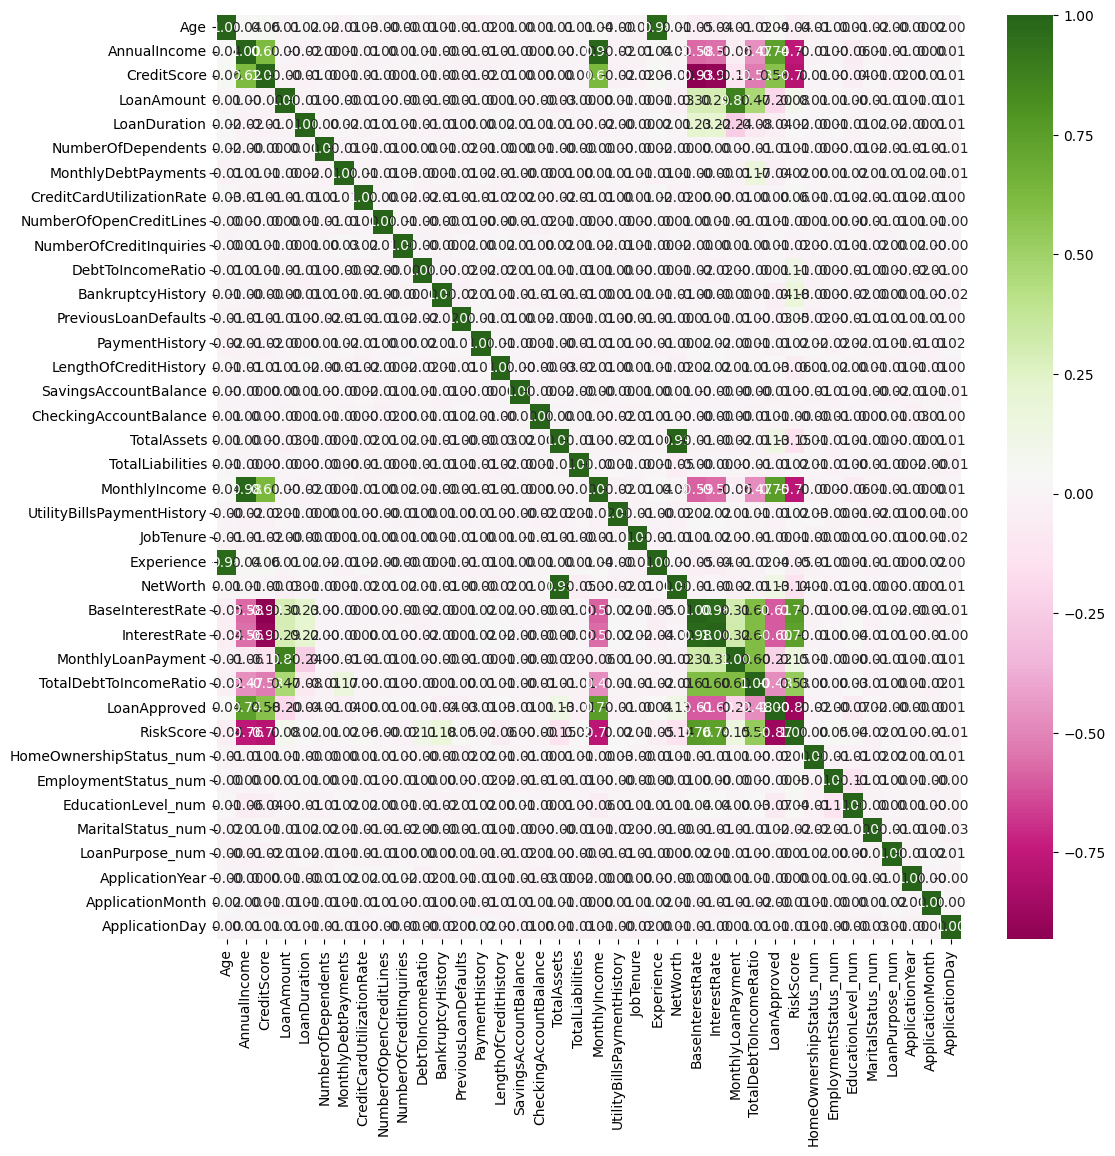

In [8]:
plt.figure(figsize=(12,12))

df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
df["ApplicationYear"] = df["ApplicationDate"].dt.year
df["ApplicationMonth"] = df["ApplicationDate"].dt.month
df["ApplicationDay"] = df["ApplicationDate"].dt.day

df_test["ApplicationDate"] = pd.to_datetime(df_test["ApplicationDate"])
df_test["ApplicationYear"] = df_test["ApplicationDate"].dt.year
df_test["ApplicationMonth"] = df_test["ApplicationDate"].dt.month
df_test["ApplicationDay"] = df_test["ApplicationDate"].dt.day

# Выбираем только числовые признаки для матрицы, категориальные нам не подходят
number_feature_count = df.select_dtypes("number").columns

print(df[number_feature_count].corr())

sns.heatmap(df[number_feature_count].corr(), annot=True, fmt=".2f", cmap="PiYG")


In [9]:

only_RiskScore_top = df[number_feature_count].corr()[["RiskScore"]]
only_RiskScore_top["ABS"] = only_RiskScore_top["RiskScore"].abs()

# Топ 10 самых связанных в DF с заполненными значениями
print(only_RiskScore_top.sort_values(by="ABS", ascending=False).head(10))



                        RiskScore       ABS
RiskScore                1.000000  1.000000
LoanApproved            -0.872722  0.872722
CreditScore             -0.785425  0.785425
MonthlyIncome           -0.770608  0.770608
BaseInterestRate         0.758712  0.758712
AnnualIncome            -0.758480  0.758480
InterestRate             0.742940  0.742940
TotalDebtToIncomeRatio   0.532384  0.532384
BankruptcyHistory        0.177559  0.177559
MonthlyLoanPayment       0.151459  0.151459



## Попробуем построить другие графики

count    9787.000000
mean        0.512108
std         0.499879
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: LoanApproved, dtype: float64
count    9787.000000
mean      677.911515
std       175.374136
min       300.000000
25%       550.000000
50%       722.000000
75%       850.000000
max       850.000000
Name: CreditScore, dtype: float64
count     9787.000000
mean     10831.569727
std       9398.941396
min       1250.000000
25%       1666.750000
50%       7339.916667
75%      21384.000000
max      25000.000000
Name: MonthlyIncome, dtype: float64
count    9787.000000
mean        0.200502
std         0.094560
min         0.052494
25%         0.119862
50%         0.182072
75%         0.265098
max         0.722497
Name: BaseInterestRate, dtype: float64
count      9787.000000
mean     131527.784510
std      116069.069481
min       15000.000000
25%       20699.500000
50%       88615.000000
75%      257780.500000
max      748508

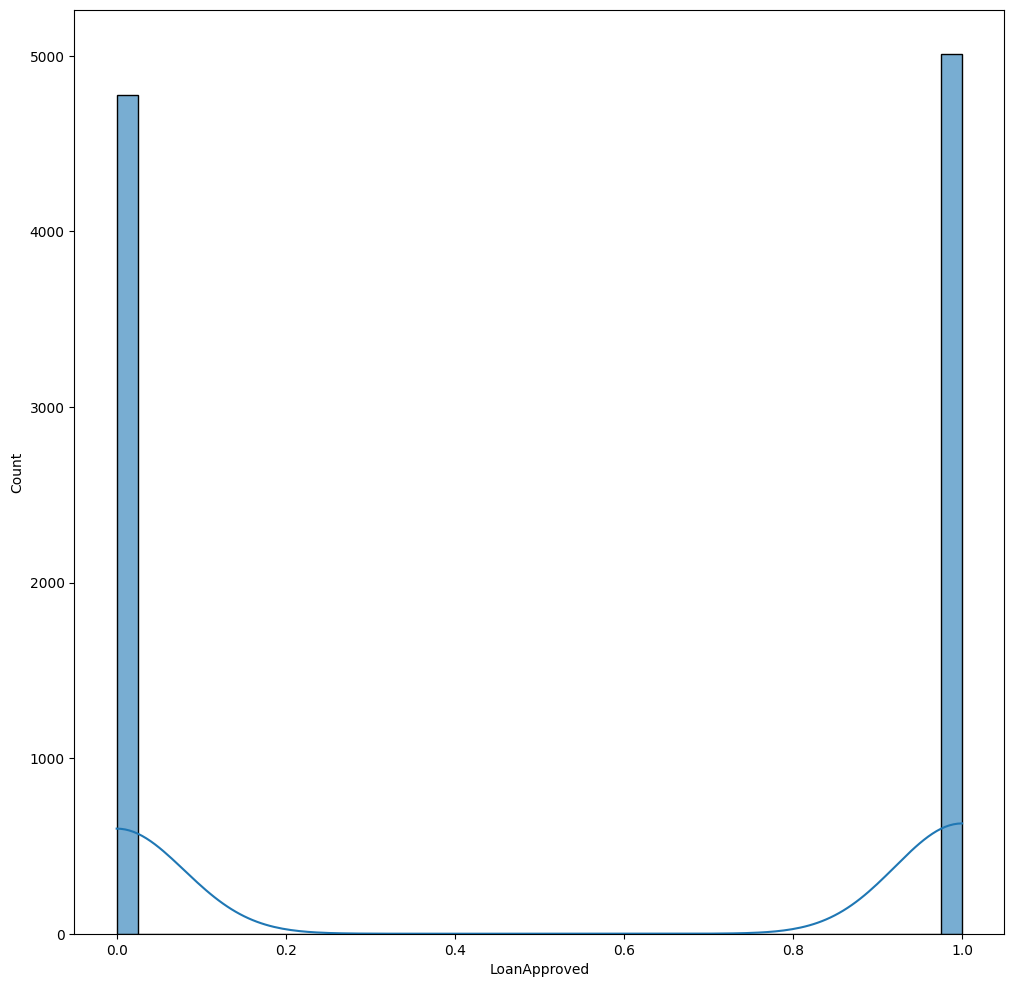

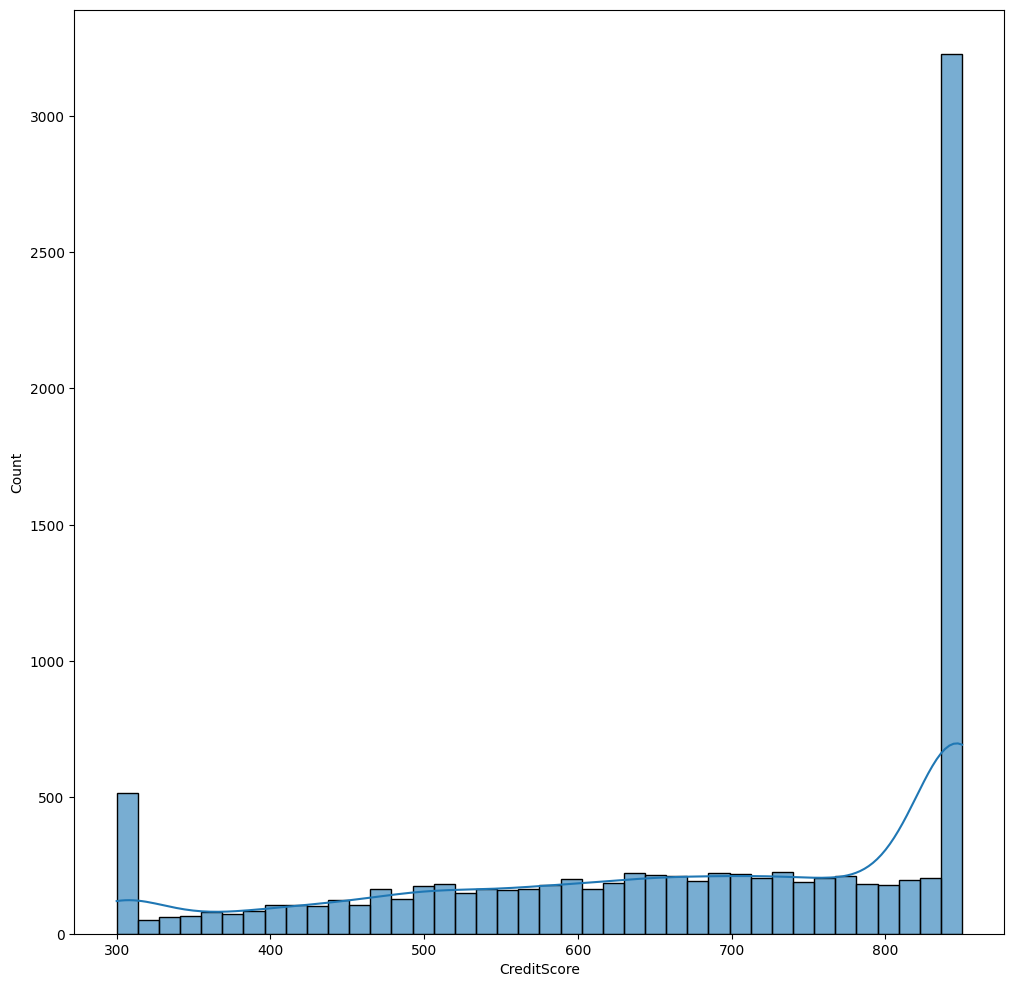

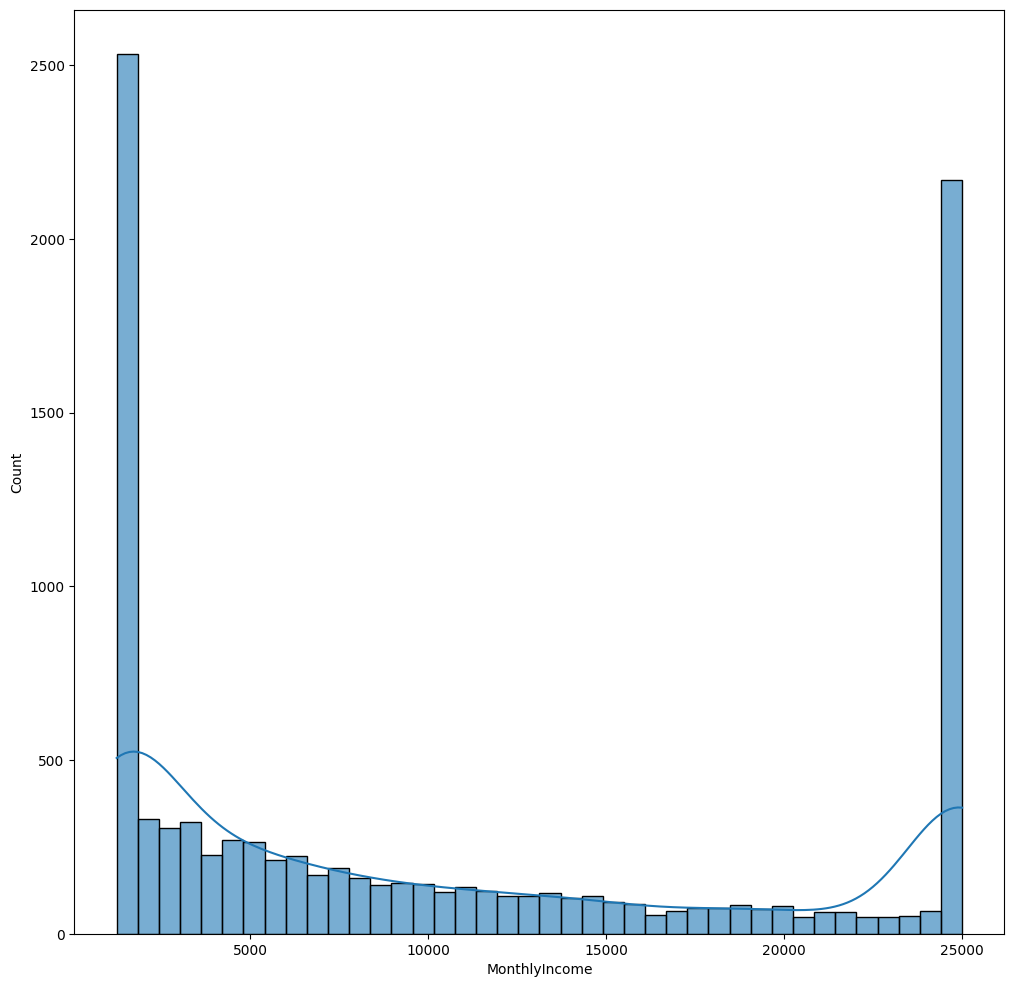

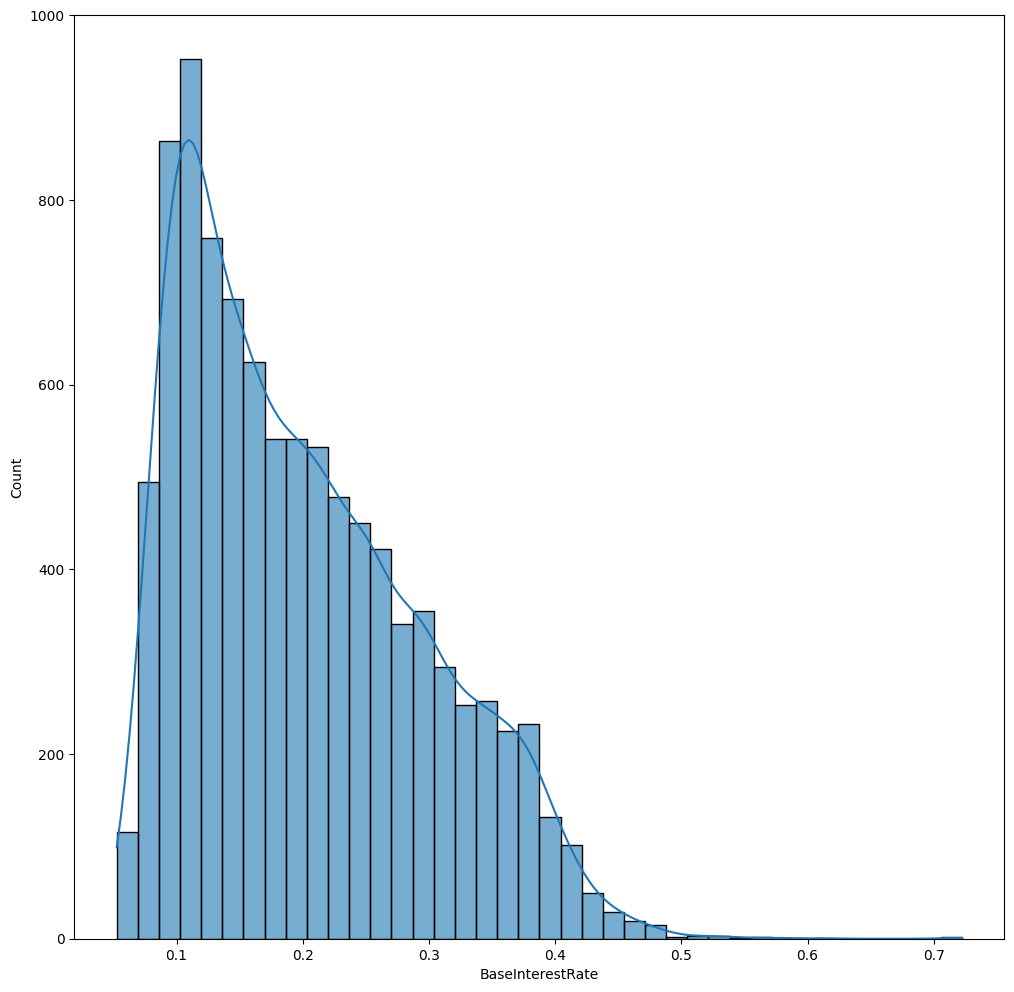

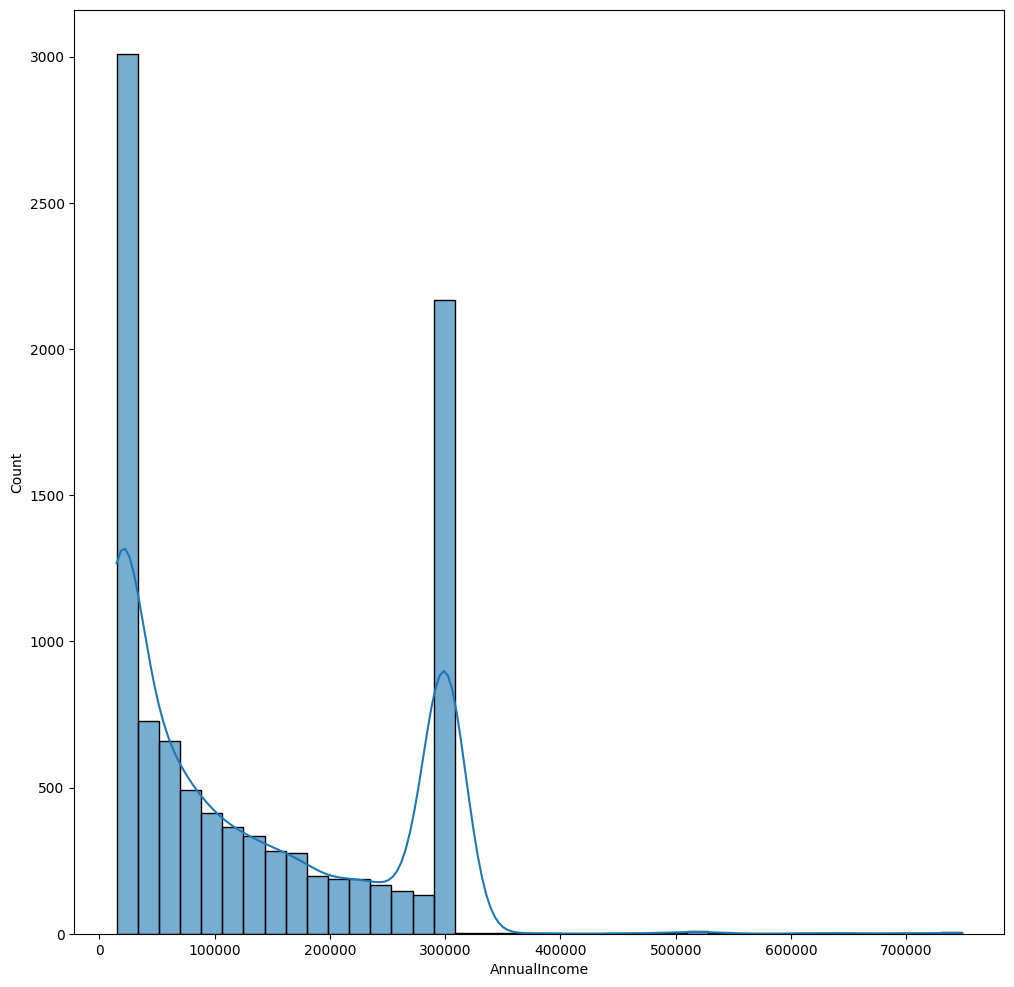

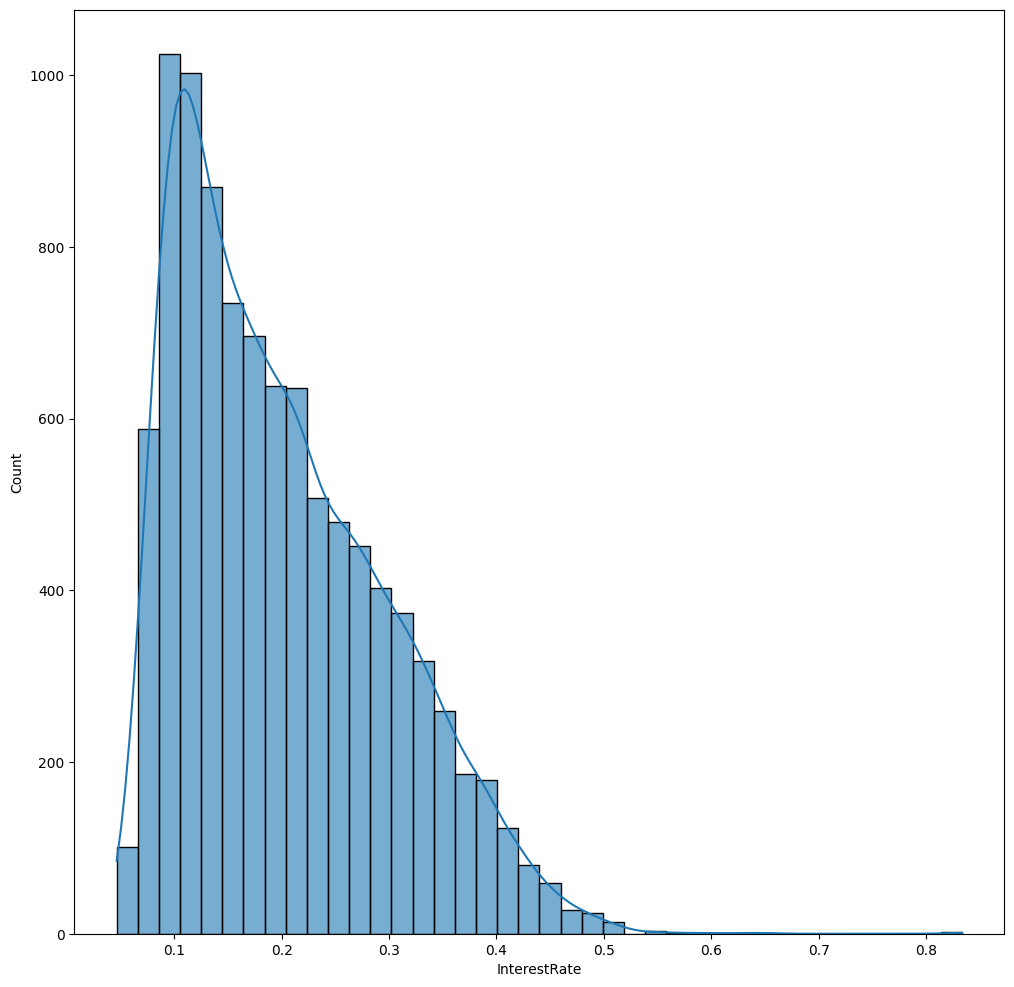

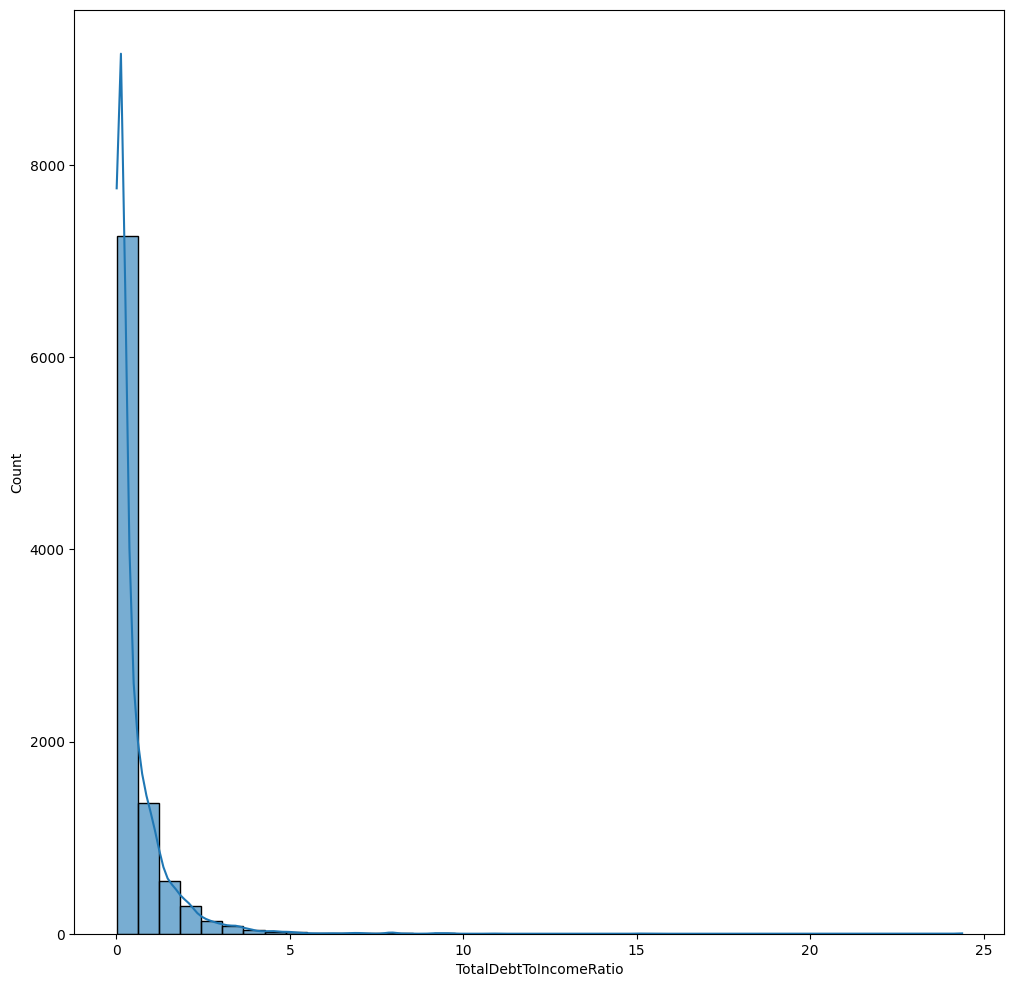

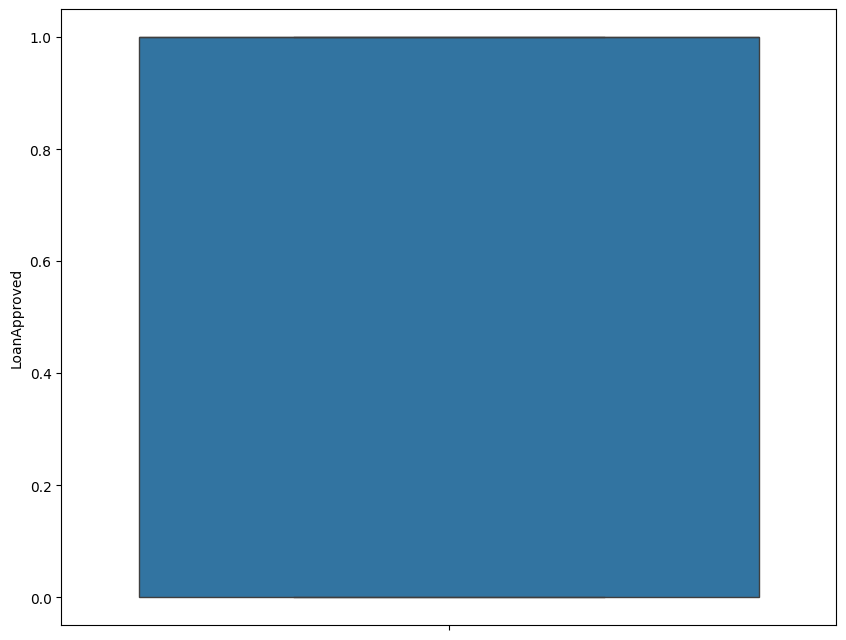

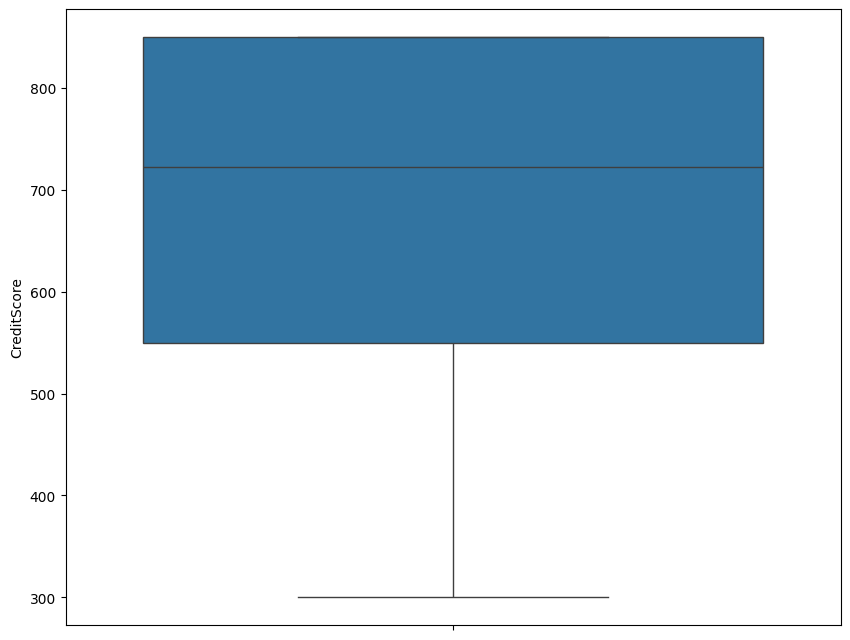

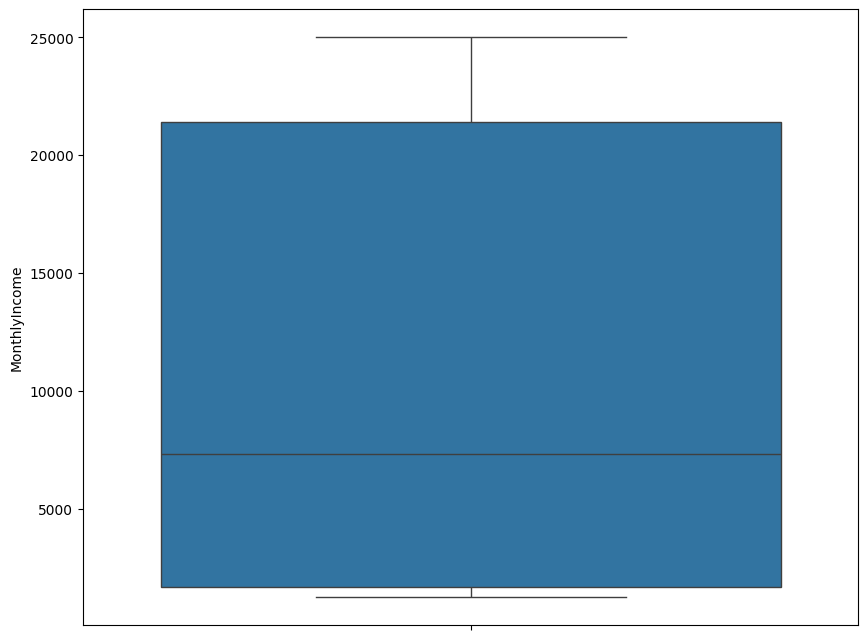

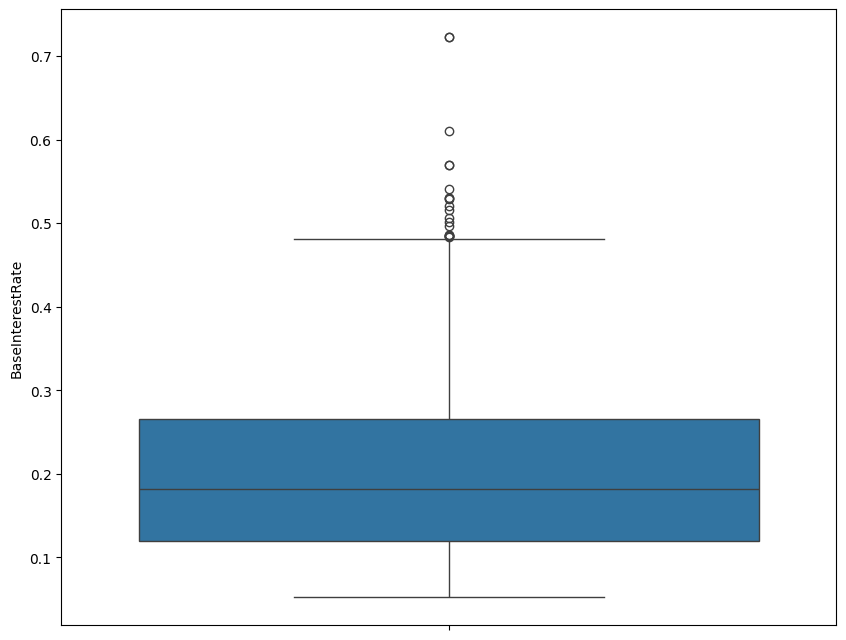

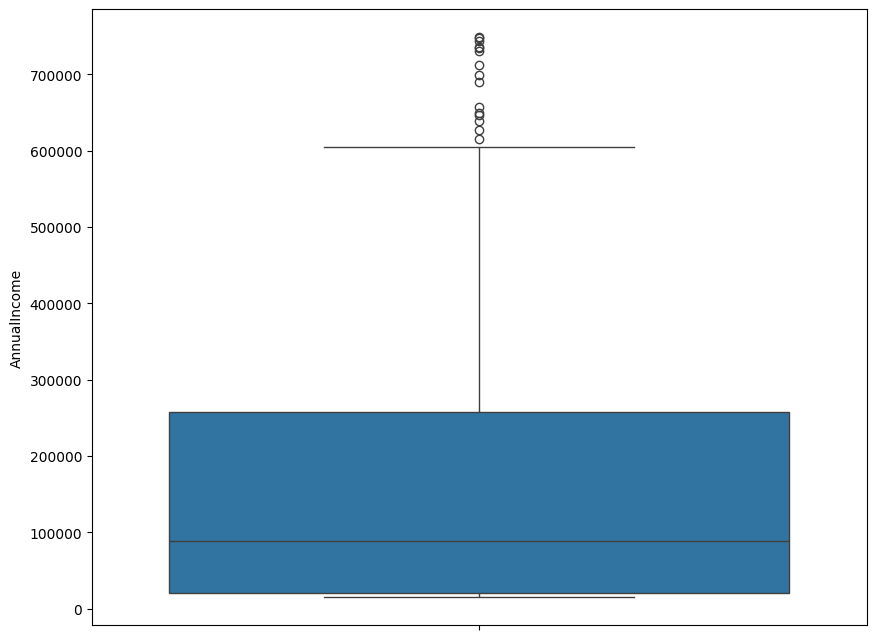

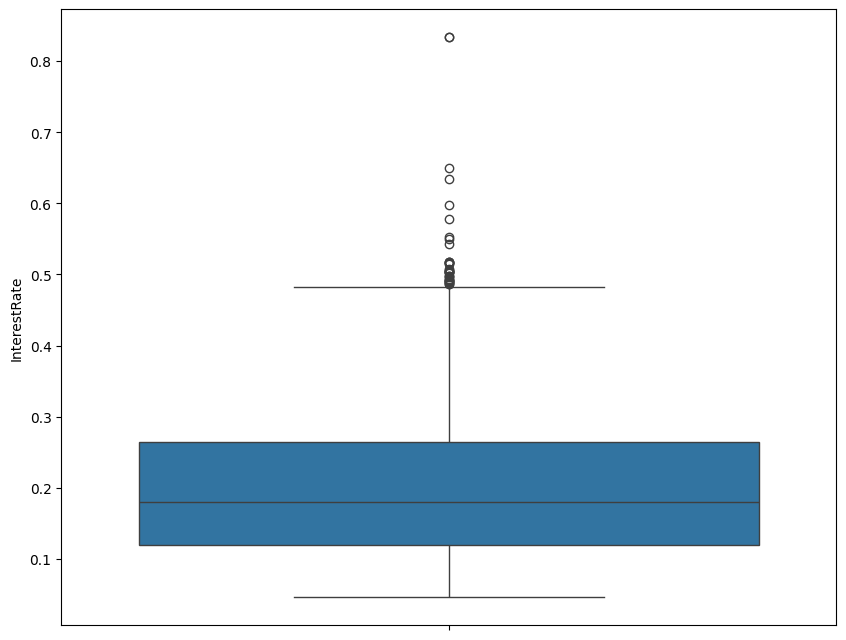

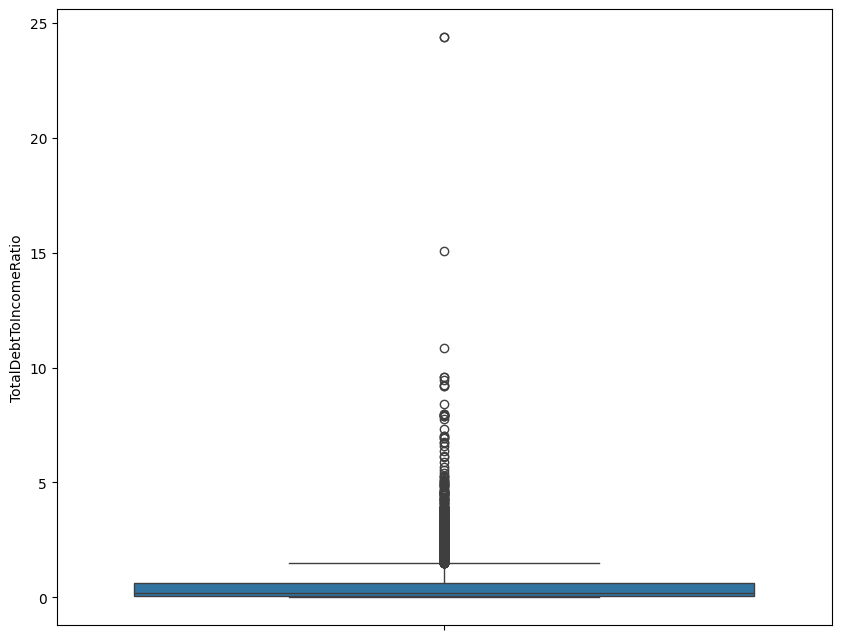

In [10]:
features = ["LoanApproved", "CreditScore", "MonthlyIncome", "BaseInterestRate", "AnnualIncome", "InterestRate", "TotalDebtToIncomeRatio"]

print(df["LoanApproved"].describe())
print(df["CreditScore"].describe())
print(df["MonthlyIncome"].describe())
print(df["BaseInterestRate"].describe())
print(df["AnnualIncome"].describe())
print(df["InterestRate"].describe())
print(df["TotalDebtToIncomeRatio"].describe())

for feature in features:
    plt.figure(figsize=(12, 12))
    sns.histplot(df[feature], bins=40, kde=True, label=feature, alpha=0.6)
    
plt.show()

# Проверим выбросы
for feature in features:
    plt.figure(figsize=(10, 8))
    sns.boxplot(df[feature])




## Попробуем убрать выбросы

2.0370958949708515
0.8145676512592778
8213
431


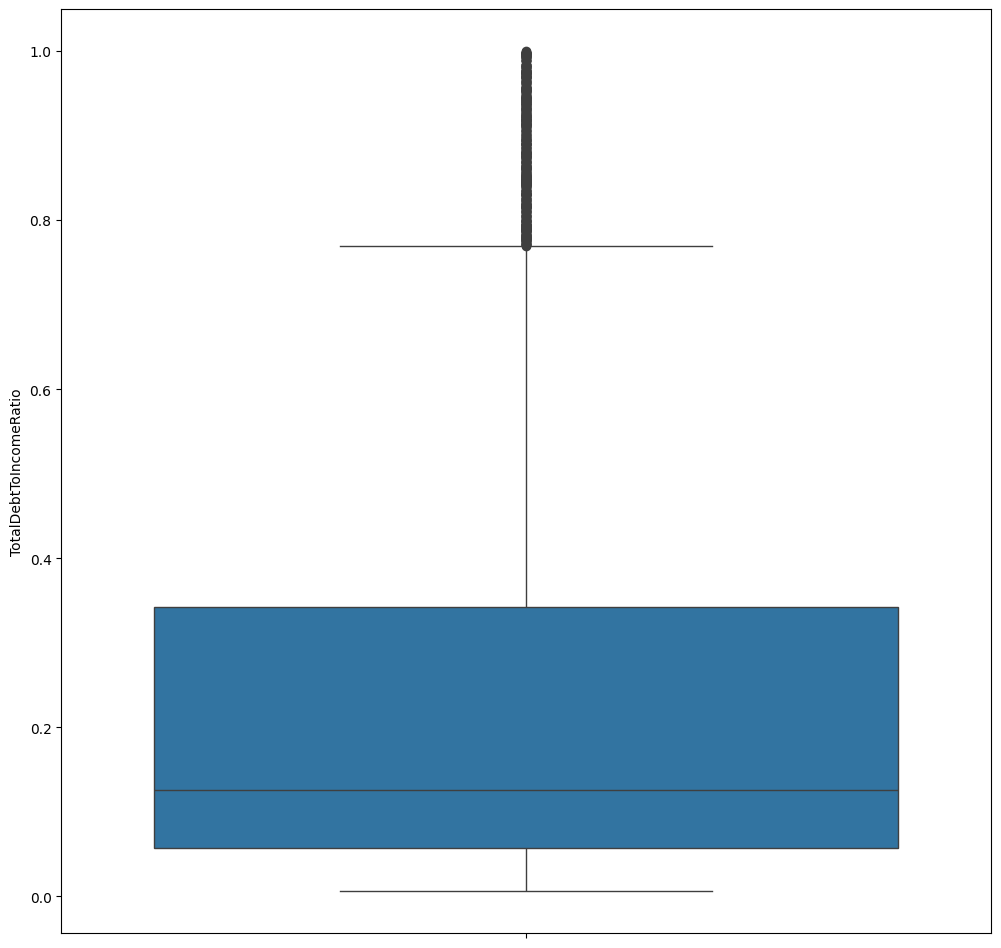

In [9]:
# Начнем с TotalDebtTolncomeRatio

print(df["TotalDebtToIncomeRatio"].quantile(0.95)) # Уберем все что больше 1, т.к макс значени это 100%
df = df[df["TotalDebtToIncomeRatio"] <= 1]

plt.figure(figsize=(12, 12))
sns.boxplot(df["TotalDebtToIncomeRatio"])

# Все равно выбросов много, надо посчитать


count = len(df["TotalDebtToIncomeRatio"])
count_more = (df["TotalDebtToIncomeRatio"] > 0.8).sum()

print(df["TotalDebtToIncomeRatio"].quantile(0.95))
print(count)
print(count_more)

0.34094782795184714


<Axes: ylabel='InterestRate'>

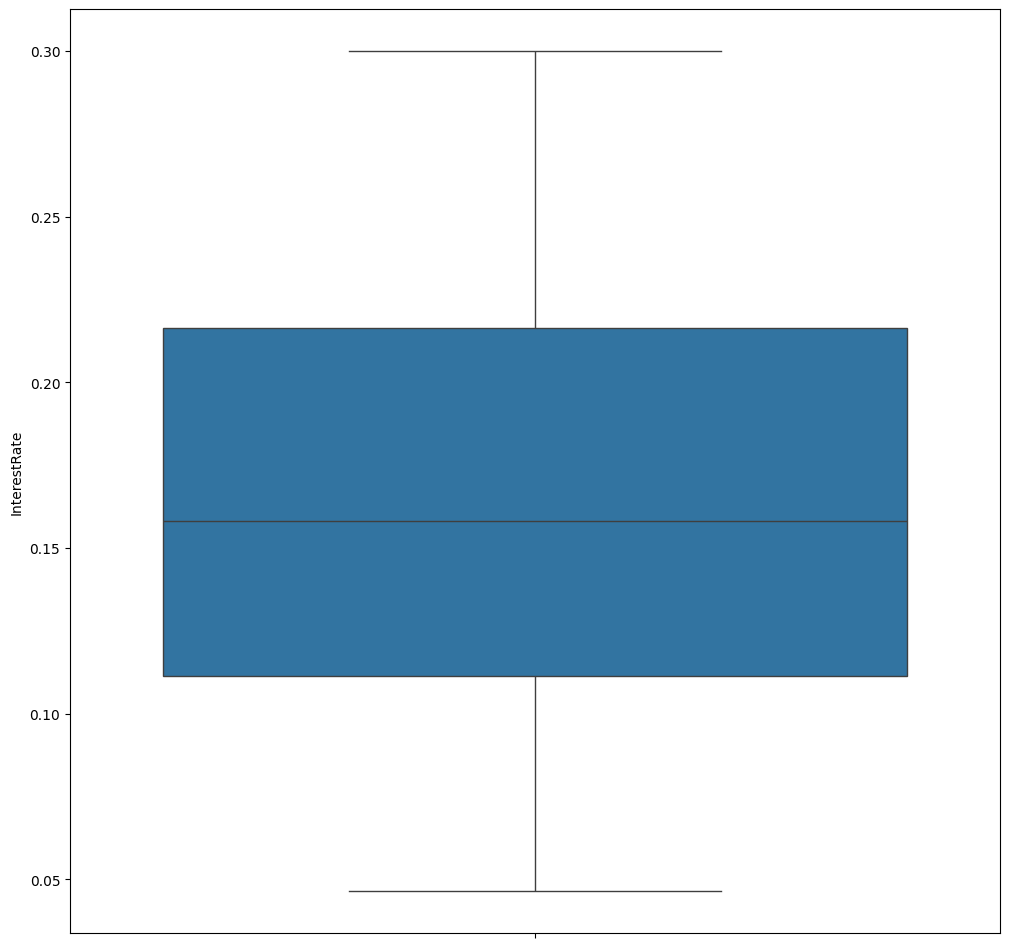

In [11]:
# Теперь с InterestRate

print(df["InterestRate"].quantile(0.9)) # Уберем все что больше 0.3

df = df[df["InterestRate"] < 0.3]
plt.figure(figsize=(12, 12))
sns.boxplot(df["InterestRate"])



300000.0
8095
45


<Axes: ylabel='AnnualIncome'>

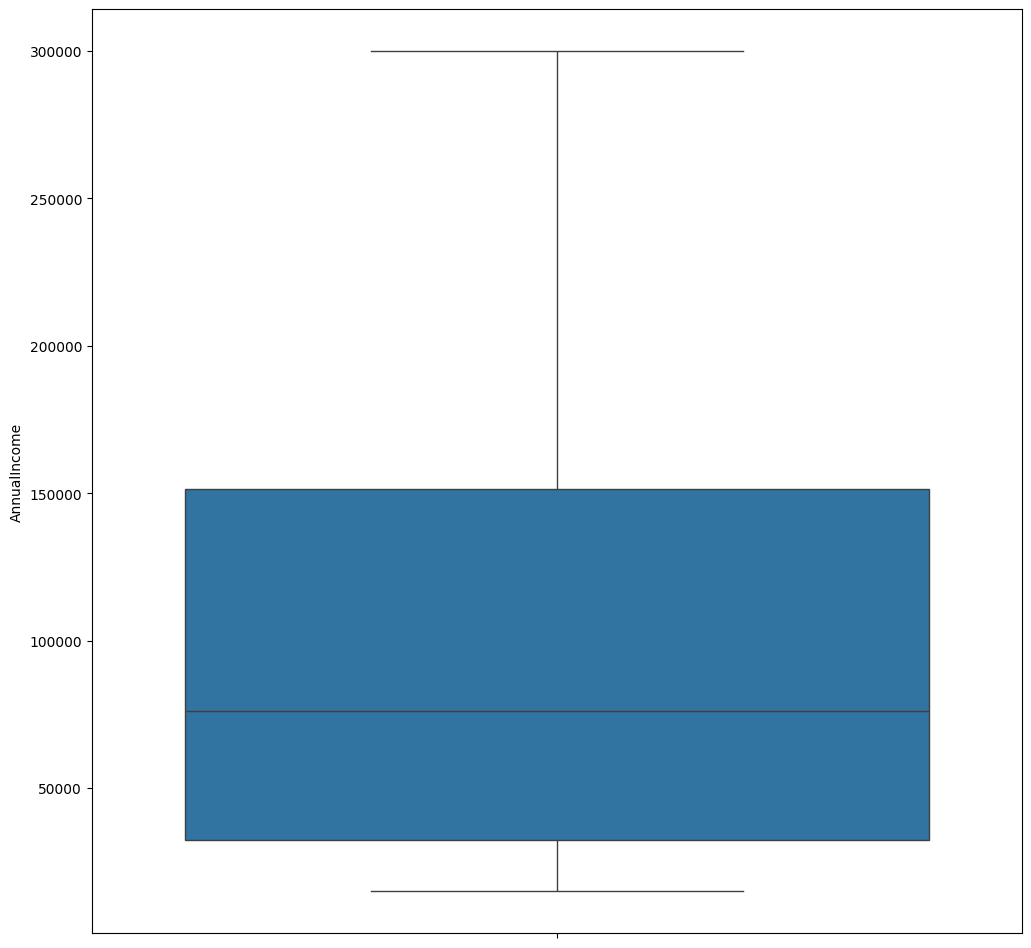

In [12]:
# Теперь с AnnualIncome

print(df["AnnualIncome"].quantile(0.75)) # Заметил что все больше 75 перцентиля равно 300000.0, остальное миллионеры 
print(len(df["AnnualIncome"]))
print((df["AnnualIncome"] > 300000.0).sum()) # примерно 3% можно удалить :)

df = df[df["AnnualIncome"] < 300000.0]
plt.figure(figsize=(12, 12))
sns.boxplot(df["AnnualIncome"])





0.293006


<Axes: ylabel='BaseInterestRate'>

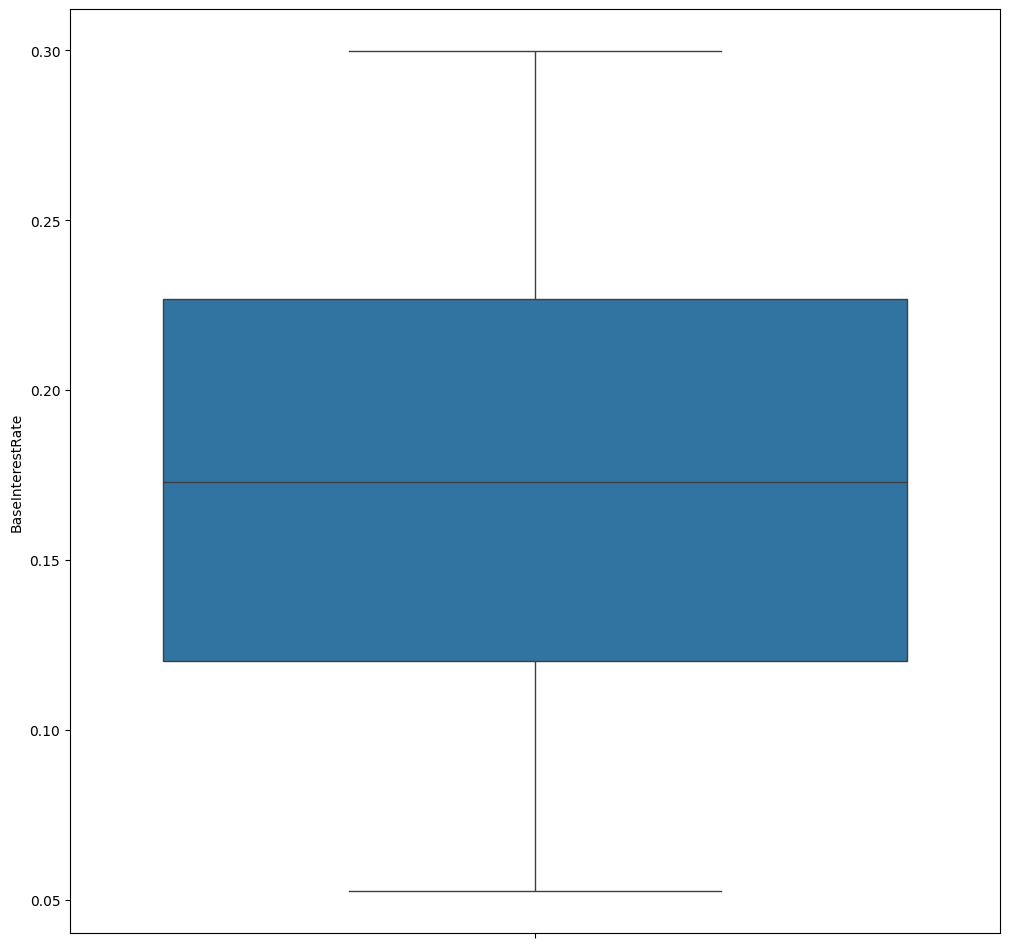

In [13]:
# Теперь с BaseInterestRate

print(df["BaseInterestRate"].quantile(0.95)) # Уберем все что больше 0.3 проц ставки

df = df[df["BaseInterestRate"] < 0.3]
plt.figure(figsize=(12, 12))
sns.boxplot(df["BaseInterestRate"])







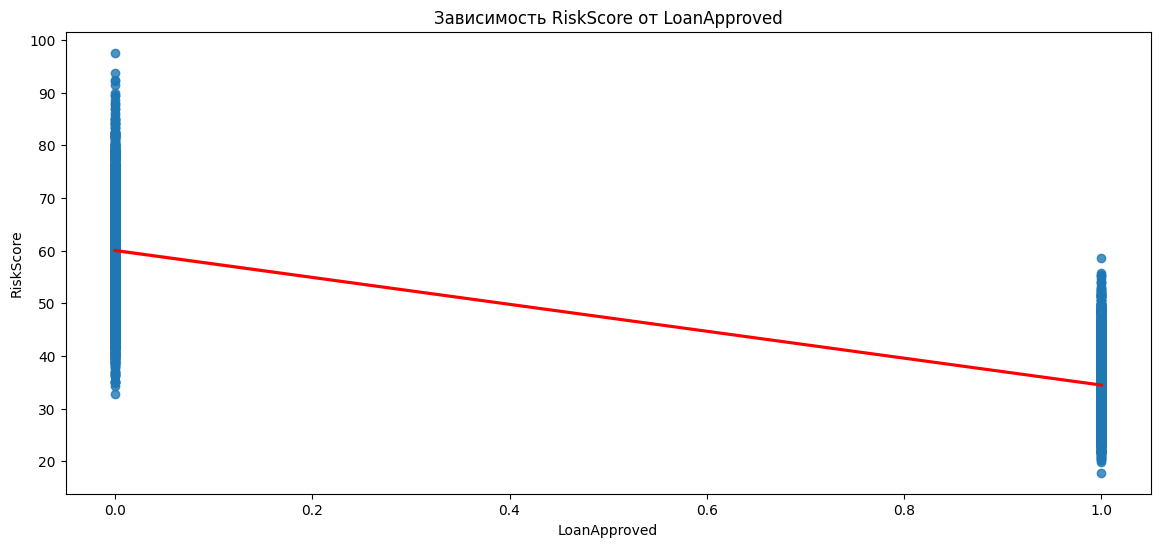

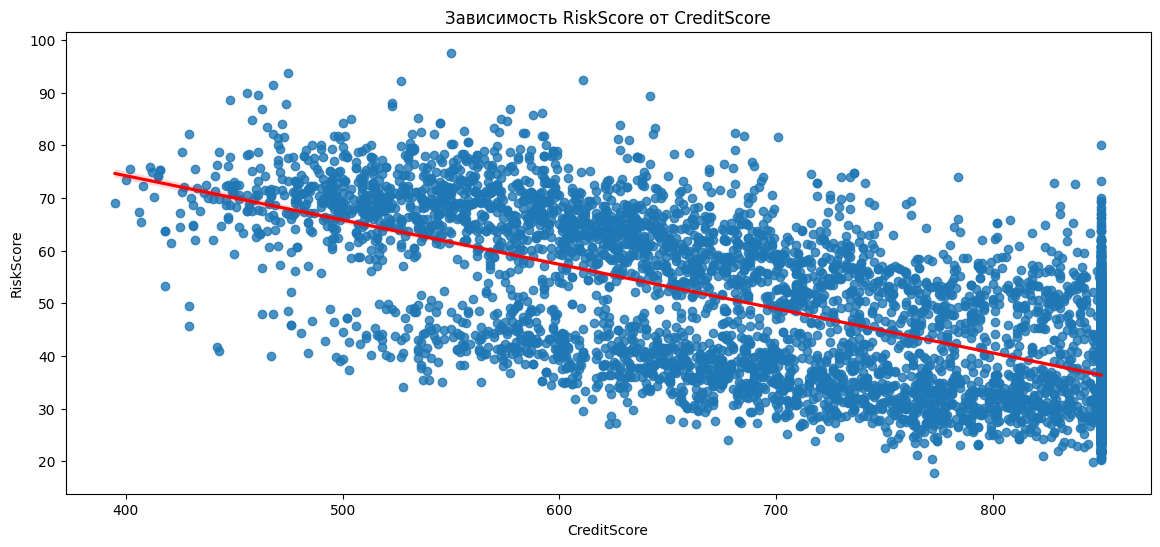

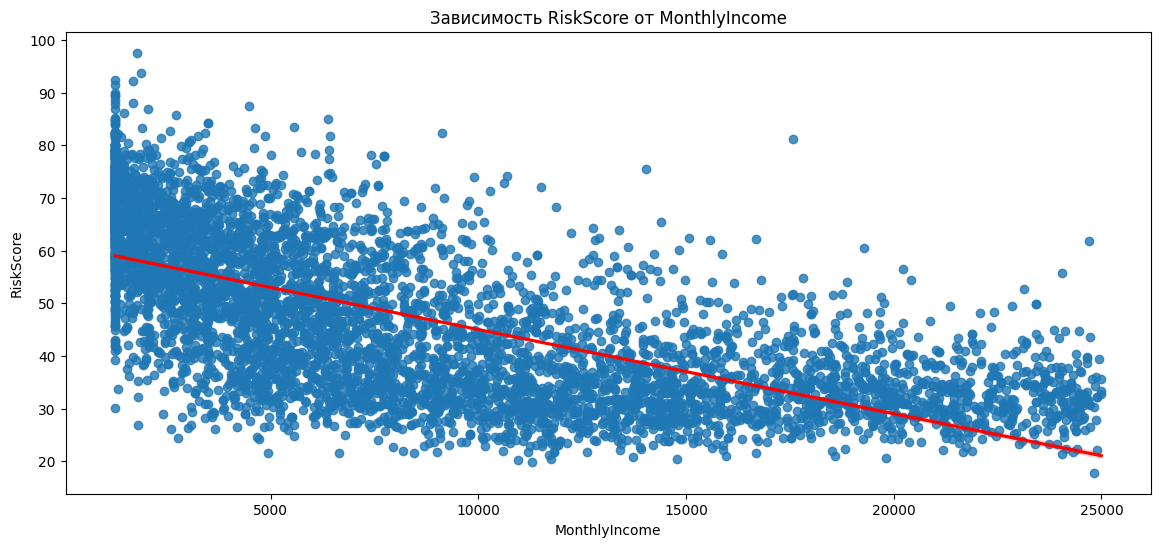

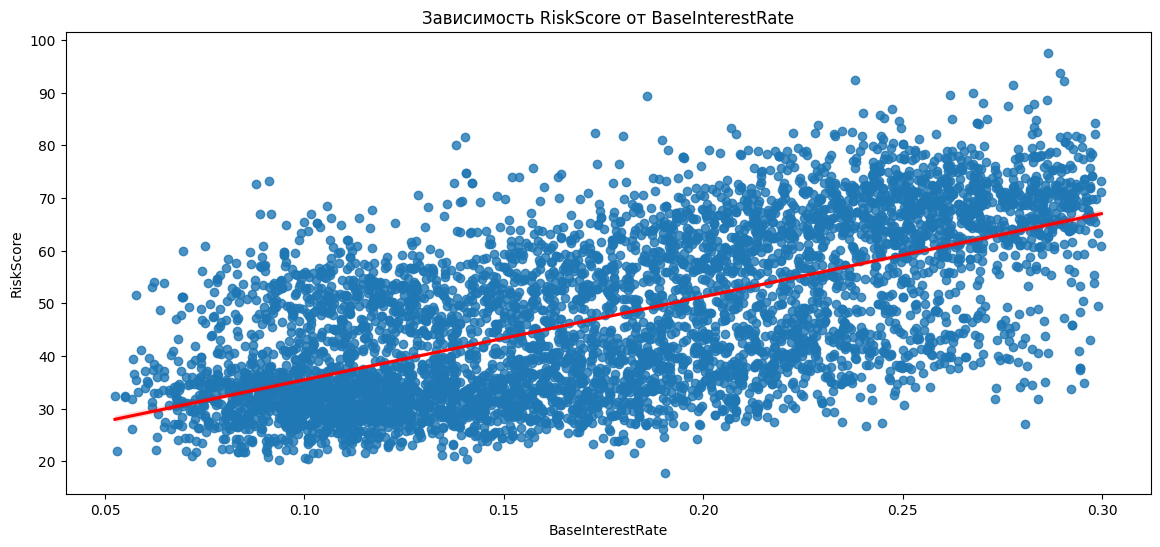

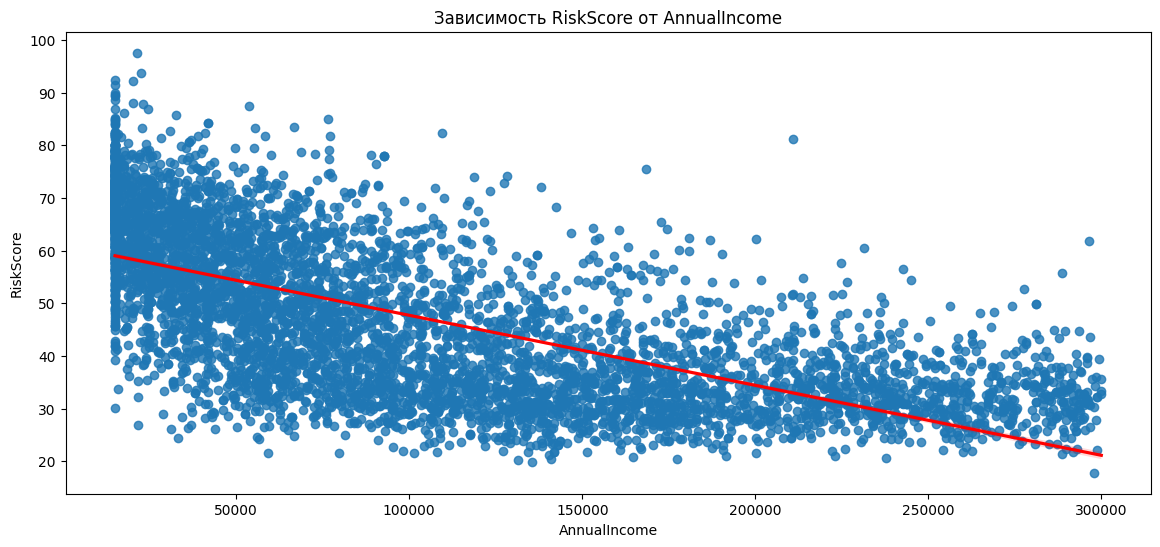

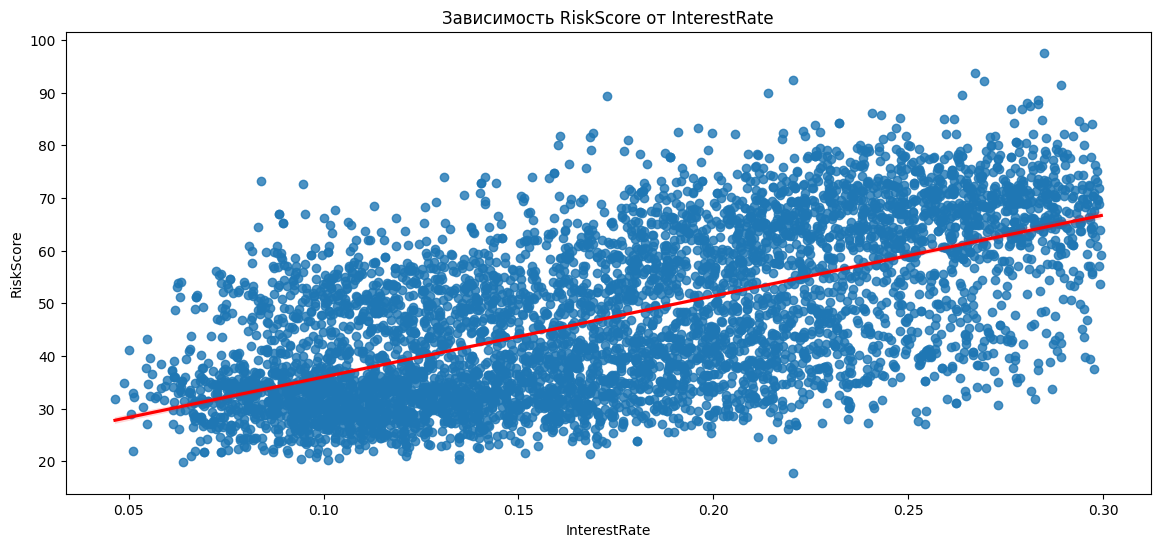

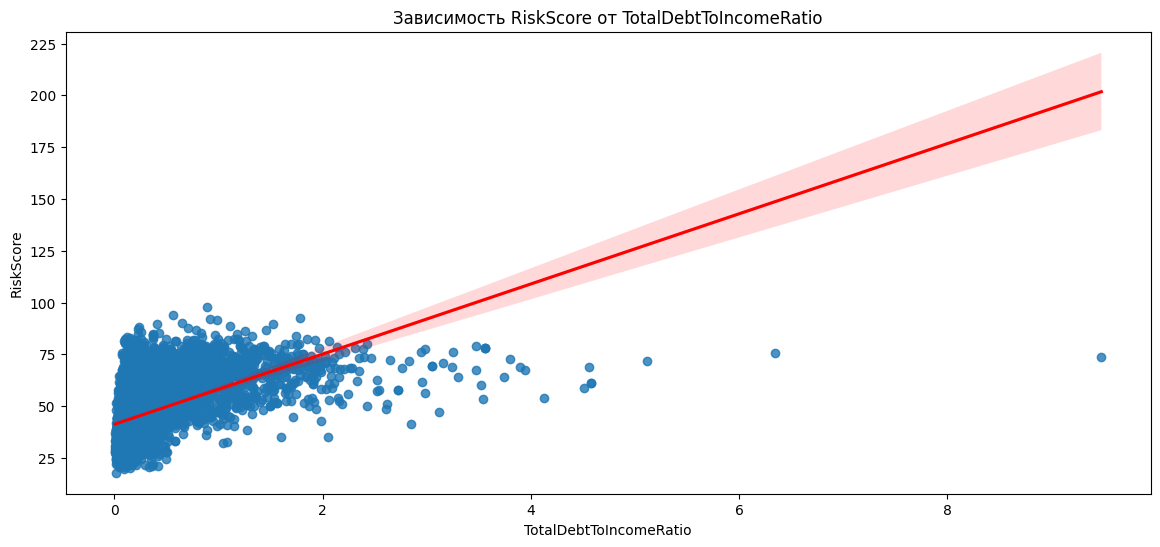

In [14]:
features = ["LoanApproved", "CreditScore", "MonthlyIncome", "BaseInterestRate", "AnnualIncome", "InterestRate", "TotalDebtToIncomeRatio"]

for feature in features :
    plt.figure(figsize=(14, 6))
    sns.regplot(x=df[feature], y=df["RiskScore"], line_kws={"color": "red"})
    plt.title(f"Зависимость RiskScore от {feature}")
    plt.show()


## Построим более точную матрицу

<Axes: >

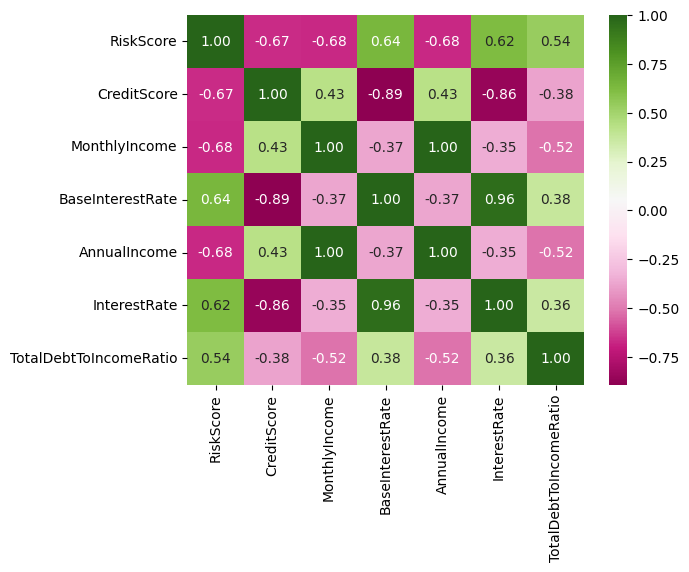

In [15]:
correlations = df[["RiskScore", "CreditScore", "MonthlyIncome", "BaseInterestRate", "AnnualIncome", "InterestRate", "TotalDebtToIncomeRatio"]].corr()

sns.heatmap(correlations, annot=True, fmt=".2f", cmap="PiYG")


# Реализуем нормализацию данных

## Z-score (стандартизация) 

### $z = \frac{x - \mu}{\sigma}$

### x - это исходное значение
### $\mu$ - это среднее значение признака
### $\sigma$ - это стандартное отклонение признака


In [16]:
# Оставляем только числовые столбцы
df_n = df.select_dtypes("number").copy()
df_test_n = df_test.select_dtypes("number").copy()

# Отделяем признаки и целевую переменную (для обучающего набора)
features = df_n.drop(columns=["RiskScore"])  
target = df_n["RiskScore"]

features_z = features.apply(lambda x: (x - x.mean()) / x.std())

df_n_z = features_z.copy()
df_n_z["RiskScore"] = target

df_test_n_z = df_test_n.apply(lambda x: (x - x.mean()) / x.std())

print(df_n_z["AnnualIncome"].mean())  # 0
print(df_n_z["AnnualIncome"].std())   # 1


-7.048544367964795e-17
1.0


## Min-Max нормализация

### $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$

### $x$ - это исходное значение
### $x_{min}$ и $x_{max}$ - минимальное и максимальное значения признака соответственно


In [17]:
features_mm = features.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

df_mm = features_mm.copy()
df_mm["RiskScore"] = target
df_mm_test = df_test_n.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Теперь все значения в диапазоне от 0 до 1

print(df_mm["AnnualIncome"].max()) # 1
print(df_mm["AnnualIncome"].min()) # 0



1.0
0.0


# Реализация класса линейной регрессии

# Вывод нормального уравнения

Пусть:

$ ( X \in \mathbb{R}^{m \times n}) $ — матрица признаков (с добавленным столбцом единиц) - т.к. наш b (bias) неудобен ввиде скаляра, и его удобно записать как еще один вес $w_{0}$, чтобы уравнение $\hat{y} = X'W + b$ превратить в $\hat{y} = XW$ где 
$$
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \dots & x_{1n} \\
1 & x_{21} & x_{22} & \dots & x_{2n} \\
1 & x_{31} & x_{32} & \dots & x_{3n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{m1} & x_{m2} & \dots & x_{mn}
\end{bmatrix}
$$

$ ( \mathbf{y} \in \mathbb{R}^{m}) $  — вектор целевых значений

$ ( \mathbf{w} \in \mathbb{R}^{n}) $ — вектор весов

$ m $ — кол-во наблюдений


**Функция потерь (MSE)**:
$$
J(\mathbf{w}) = \frac{1}{2m} \| X\mathbf{w} - \mathbf{y} \|^2
$$

1. **Находим градиент функции потерь**:
$$
\nabla_{\mathbf{w}} J(\mathbf{w}) = \frac{1}{m} X^\top (X\mathbf{w} - \mathbf{y})
$$

2. **Приравниваем градиент к нулю (чтобы инимизировать функцию стоимости)**:
$$
X^\top (X\mathbf{w} - \mathbf{y}) = \mathbf{0}
$$

3. **Раскрываем скобки**:
$$
X^\top X\mathbf{w} = X^\top \mathbf{y}
$$

4. **Решаем**:
$$
\boxed{\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}}
$$


## Вывод градиентного спуска

## Функция потерь (MSE)
Среднеквадратичная ошибка в матричной форме:
$$
J(\mathbf{w}) = \frac{1}{2m} \| X\mathbf{w} - \mathbf{y} \|^2 = \frac{1}{2m} (X\mathbf{w} - \mathbf{y})^\top (X\mathbf{w} - \mathbf{y}),
$$


---

## Шаги вычисления градиента

### 1. Раскрываем квадрат нормы
$$
J(\mathbf{w}) = \frac{1}{2m} \left[ \mathbf{w}^\top X^\top X \mathbf{w} - 2 \mathbf{w}^\top X^\top \mathbf{y} + \mathbf{y}^\top \mathbf{y} \right].
$$

### 2. Дифференцируем по $(\mathbf{w})$
Используем правила матричного дифференцирования:

1. **Производная квадратичной формы**:
   $$
   \frac{\partial}{\partial \mathbf{w}} (\mathbf{w}^\top X^\top \mathbf{w} X ) = 2 X^\top X \mathbf{w}.
   $$

2. **Производная линейного члена**:
   $$
   \frac{\partial}{\partial \mathbf{w}} (-2 \mathbf{w}^\top X^\top \mathbf{y}) = -2 X^\top \mathbf{y}.
   $$

3. **Производная константы**:
   $$
   \frac{\partial}{\partial \mathbf{w}} (\mathbf{y}^\top \mathbf{y}) = 0.
   $$

### 3. Собираем все компоненты
$$
\nabla_{\mathbf{w}} J(\mathbf{w}) = \frac{1}{2m} \left( 2 X^\top X \mathbf{w} - 2 X^\top \mathbf{y} \right).
$$

---

## Итоговая формула градиента
$$
\boxed{
\nabla_{\mathbf{w}} J(\mathbf{w}) = \frac{1}{m} X^\top (X\mathbf{w} - \mathbf{y})
}
$$

---

## Пояснение
- **Градиент** показывает направление наискорейшего роста функции потерь.
- **Отрицательный градиент** $(-\nabla J)$ указывает направление минимизации ошибки.
- Формула используется в градиентном спуске для обновления весов:
  $$
  \mathbf{w}_{j} = \mathbf{w}_{j-1} - \alpha \cdot \nabla_{\mathbf{w}} J(\mathbf{w}),
  $$
  где $\alpha$ — скорость обучения.


In [26]:
import numpy as np

class LinearRegression:
    def __init__(self, method="analytical", learning_rate=0.01, iter=1e4) :
        self.method = method
        self.learning_rate = learning_rate # нужна для корректировки узнать какой
        self.iter = int(iter)
        self.weights = None

    def add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]
    
    def fit(self, X, y):
        # Добавляем единичный столбец
        X = self.add_bias(X)
        m = X.shape[0] # кол-во объектов
        n = X.shape[1] # кол-во признаков

        
        if self.method == "analytical":
            self.weights = np.linalg.inv(X.T @ X) @ X.T @ y
        elif self.method == "gradient":
            # Для начала инициализируем вектор весов нулями. ГС быстро исправит ошибки
            self.weights = np.zeros(n)

            for i in range(self.iter):
                gradient = (1 / m) * (X.T @ (X @ self.weights - y)) # X @ self.weights - это наше предсказание, а y - это реальное значение
                self.weights -= self.learning_rate * gradient # обновляем веса, так, чтобы функция потерь уменьшилась, тк градиент показывает в каком направлении изменять веса, чтобы ошибка снижалась

        else:
            raise ValueError("Метод должен быть 'analytical', 'gradient' или 'sgradient'")


    def predict(self, X):
        X = self.add_bias(X)
        return X @ self.weights
            
            
            
    

In [31]:
model = LinearRegression(method="gradient")

X = df_n_z.drop("RiskScore", axis=1).values
X_test = df_test_n_z.drop(columns=["ID"]).values
y = df_n_z["RiskScore"].values 

model.fit(X, y)

predictions = model.predict(X_test)
 
submission_df = pd.DataFrame({
    "ID": test_ids,
    "RiskScore": predictions
})

submission_df.to_csv("kaggle_submission.csv", index=False)

In [20]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X, y)  
predictions_sklearn = sklearn_model.predict(X_test) 


In [30]:
from sklearn.metrics import mean_squared_error

mse_custom = mean_squared_error(y, model.predict(X))  # Твоя модель
mse_sklearn = mean_squared_error(y, sklearn_model.predict(X))  # Sklearn

print(f"MSE твоей модели: {mse_custom}")
print(f"MSE sklearn модели: {mse_sklearn}")

def mse(y_true, y_pred):
    return ((y_true - y_pred) ** 2).mean()

print(f"MSE: {mse(y, model.predict(X)):.4f}")


MSE твоей модели: 16.98818504571064
MSE sklearn модели: 16.969229263220374
MSE: 16.9882
